# Layer wise relevance propagation of the sub_model

Source:  
https://github.com/seongun-kim/1210_dtd_ig/blob/master/methods/deep_taylor_decomposition.py

The backpropagation rule:   
∀k : sk = Rk/zk (element-wise division)  
for the convolutional layer is violated due to matrix dimension incompatibility.  
Therefore, the influence on the relevance of this layer is neglected.  
More information in the book:  
Explainable AI: Interpreting, Explaining and Visualizing Deep Learning, page 197 by Wojciech Samek, Grégoire Montavon, Andrea Vedaldi, Lars Kai Hansen, Klaus-Robert Müller (Eds.).

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import random

from sklearn.model_selection import train_test_split

import keras

import tensorflow as tf
from tensorflow.keras import layers, models

2025-11-01 18:35:09.668078: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-11-01 18:35:09.668228: I external/local_tsl/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-11-01 18:35:09.669777: I external/local_tsl/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-11-01 18:35:09.688233: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-11-01 18:35:10.126028: W tensorflow/compiler/tf2tensorrt/uti

In [2]:
def set_reproducible():
    np.random.seed(12345)
    random.seed(12345)
    tf.random.set_seed(12345)
    
set_reproducible()

In [3]:
dps1200 = pd.read_csv("../../data/dps1200.csv")

In [4]:
dps1200.rename(columns=lambda x: x.replace('X', ''), inplace=True)

In [5]:
features = dps1200.iloc[:, 4:].values
labels = dps1200.iloc[:, 0].values

In [6]:
train_data, test_data, train_labels, test_labels = train_test_split(features, labels, test_size=0.2, random_state=42)

In [7]:
model_path = "dps1200sub_model.keras"

In [8]:
dps1200sub_model = tf.keras.models.load_model(model_path)

# Show the model architecture
dps1200sub_model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 410, 1)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 205, 64)   │        832 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 205, 64)   │        256 │ conv1d[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 205, 64)   │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d       │ (None, 103, 64)   │          0 │ activation[0][0]  │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 103, 32)   │      2,048 │ max_pooling1d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 103, 32)   │        128 │ conv1d_1[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 103, 32)   │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 103, 32)   │      3,072 │ activation_1[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_3 (Conv1D)   │ (None, 103, 64)   │     14,336 │ activation_1[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_4 (Conv1D)   │ (None, 103, 32)   │     11,264 │ activation_1[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 103, 128)  │          0 │ conv1d_2[0][0],   │
│ (Concatenate)       │                   │            │ conv1d_3[0][0],   │
│                     │                   │            │ conv1d_4[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_5 (Conv1D)   │ (None, 103, 128)  │     16,384 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_6 (Conv1D)   │ (None, 103, 128)  │      8,192 │ max_pooling1d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 103, 128)  │        512 │ conv1d_5[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 103, 128)  │        512 │ conv1d_6[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 103, 128)  │          0 │ batch_normalizat… │
│                     │                   │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 103, 128)  │          0 │ add[0][0]         │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_7 (Conv1D)   │ (None, 103, 32)   │      4,096 │ activation_2[0][

 Total params: 1,630,021 (6.22 MB)

 Trainable params: 542,401 (2.07 MB)

 Non-trainable params: 2,816 (11.00 KB)

 Optimizer params: 1,084,804 (4.14 MB)

# LRP

In [9]:
for i, layer in enumerate(dps1200sub_model.layers):
    print(f"Layer {i+1}: {layer.name}")
    if hasattr(layer, 'weights') and layer.weights:
        weights, biases = layer.get_weights()
        print(f"Weights shape: {weights.shape}")
        print(f"Biases shape: {biases.shape}")
    else:
        print("No weights in this layer.")


Layer 1: input_layer
No weights in this layer.
Layer 2: conv1d


ValueError: not enough values to unpack (expected 2, got 1)

In [11]:
print(dps1200sub_model.inputs[0])

<KerasTensor shape=(None, 410, 1), dtype=float32, sparse=False, name=input_layer>


In [12]:
class DTD:
    def __init__(self, sess, dataset, model):
        # Tensorflow session.
        self.sess = sess
        # Dataset.
        self.ds = dataset
        self.model = model

        def get_all_activations(model, input_data):
            
            all_activations = []
        
            for layer in model.layers:
                intermediate_layer_model = tf.keras.Model(inputs=model.inputs,
                                                        outputs=layer.output)
                layer_activations = intermediate_layer_model.predict(input_data)
                all_activations.append(layer_activations)
        
            return all_activations
    
    # Load model parameter for explanation.
        self.X = model.inputs
        self.pred = model.outputs        
        self.conv_w_1 = model.layers[1]
        self.conv_w_2 = model.layers[2]
        self.conv_w_3 = model.layers[3]
        self.fc_w_1 =  model.layers[7]
        self.fc_w_2 = model.layers[8]
        self.fc_w_3 = model.layers[9]
        self.fc_w_4 = model.layers[10]
        self.activations = get_all_activations(model, dataset)
        
    
    def backprop_dense_z_plus(self, activation, layer : keras.layers.Dense, relevance):
        kernel = layer.kernel.numpy()
        W_p = np.maximum(np.zeros_like(kernel), kernel)
        z = np.matmul(activation, W_p) + 1e-9
        s = relevance / z
        c = np.matmul(s, np.transpose(W_p))
        return activation * c
     
    
    def simple_backprop(self, activation, layer : keras.layers.Conv1D, relevance, padding='valid'):
        kernel = layer.kernel.numpy()
        W_p = np.maximum(np.zeros_like(kernel), kernel)
        c = keras.ops.conv_transpose(relevance, W_p, [1], padding=padding)
        return c
    
    def backprop_y_pooling_2(self, prev_activation : np.array, relevance : np.array):
        result_relevance = np.zeros_like(prev_activation)

        for x in range(relevance.shape[0]):
            for y in range(relevance.shape[1]):
                for z in range(relevance.shape[2]):
                    left = prev_activation[x,y*2,z]
                    right = prev_activation[x,y*2+1,z]

                    if left > right:
                        result_relevance[x,y*2,z] = relevance[x,y,z]
                    elif left < right:
                        result_relevance[x,y*2+1,z] = relevance[x,y,z]
                    else:
                        result_relevance[x,y*2+1,z] = relevance[x,y,z]
                        result_relevance[x,y*2,z] = relevance[x,y,z]
        
        return result_relevance


    def run(self):
        # Initialize a list of relevance.
        Rs = []

        # Assign relevance to the output.
        relevance = self.activations[-1]
        Rs.append(relevance)
        
        # fc_layer_4
        relevance = self.backprop_dense_z_plus(self.activations[-2], self.fc_w_4, Rs[-1])
        Rs.append(relevance)

        # fc_layer_3
        relevance = self.backprop_dense_z_plus(self.activations[-3], self.fc_w_3, Rs[-2])
        Rs.append(relevance)

        # fc_layer_2
        relevance = self.backprop_dense_z_plus(self.activations[-4], self.fc_w_2, Rs[-3])
        Rs.append(relevance)
        
        # fc_layer_1
        relevance = self.backprop_dense_z_plus(self.activations[-5], self.fc_w_1, Rs[-4])
        Rs.append(relevance)

        #omit dropout layer
        Rs.append(relevance)
        
        # Flatten
        relevance = np.reshape(Rs[-1], self.activations[4].shape)
        Rs.append(relevance)

        # Pooling
        relevance = self.backprop_y_pooling_2(self.activations[3], Rs[-1])
        Rs.append(relevance)

        # conv_3
        relevance = self.simple_backprop(self.activations[3], self.conv_w_3, Rs[-1])
        Rs.append(relevance)
        
        # conv_2
        relevance = self.simple_backprop(self.activations[2], self.conv_w_2, Rs[-1])
        Rs.append(relevance)
        
        # conv_1
        relevance = self.simple_backprop(self.activations[1], self.conv_w_1, Rs[-1])
        Rs.append(relevance)

        return Rs

In [13]:
back = DTD(dps1200sub_model, test_data, dps1200sub_model)
rel = back.run()

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 876us/step
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
9/9 ━━━━━━━━━━━━━━━━

ValueError: matmul: Input operand 1 has a mismatch in its core dimension 0, with gufunc signature (n?,k),(k,m?)->(n?,m?) (size 32 is different from 64)

In [ ]:
print(rel[-1])
rele = keras.ops.convert_to_numpy(rel[-1])
rele = np.max(rele, 2)
print(rele.shape)

tf.Tensor(
[[[ 237.59059]
  [1035.9941 ]
  [1960.1445 ]
  ...
  [1353.7288 ]
  [ 670.08704]
  [   0.     ]]

 [[ 203.13469]
  [1509.5974 ]
  [2872.0474 ]
  ...
  [1381.5958 ]
  [ 643.6513 ]
  [   0.     ]]

 [[ 307.41507]
  [ 739.166  ]
  [1416.322  ]
  ...
  [ 886.5115 ]
  [ 396.32224]
  [   0.     ]]

 ...

 [[ 353.0609 ]
  [1554.1514 ]
  [2928.294  ]
  ...
  [1284.7651 ]
  [ 596.38715]
  [   0.     ]]

 [[ 817.9755 ]
  [1589.5453 ]
  [2718.7988 ]
  ...
  [1590.484  ]
  [ 760.2381 ]
  [   0.     ]]

 [[ 246.21187]
  [1086.2081 ]
  [2056.4004 ]
  ...
  [2074.837  ]
  [1027.1891 ]
  [   0.     ]]], shape=(258, 410, 1), dtype=float32)
(258, 410)


In [ ]:
import seaborn as sns

In [ ]:
y = dps1200.iloc[:,4:]
xp = y.columns.values
xp = xp.astype(int)

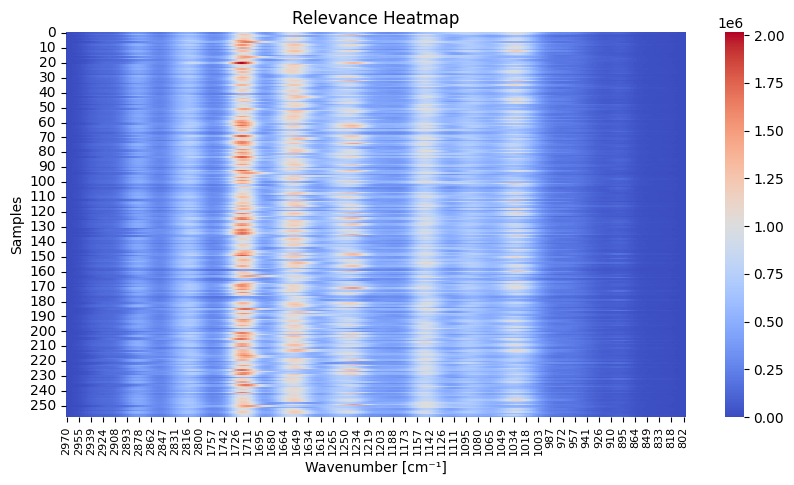

In [ ]:
# Plot Heatmap
wavelengths = xp[::8]

# Plot Heatmap
plt.figure(figsize=(10, 5))
sns.heatmap(rele, cmap='coolwarm')
plt.xlabel('Wavenumber [cm⁻¹]')
plt.ylabel('Samples')
plt.title('Relevance Heatmap')
plt.xticks(ticks=np.arange(0.5, rele.shape[1] + 0.5, 8), labels=wavelengths, fontsize=8)
plt.show()

# Heatmap with sorted data according to the years

In [ ]:
test_labels_2d = test_labels.reshape(-1, 1)
test_data_all = np.concatenate((test_labels_2d, rele), axis=1)


sorted_indices = np.argsort(test_data_all[:, 0])
test_all_sorted = test_data_all[sorted_indices]

sorted_test_labels = test_all_sorted[:, 0]
sorted_rele_data = test_all_sorted[:, 1:]

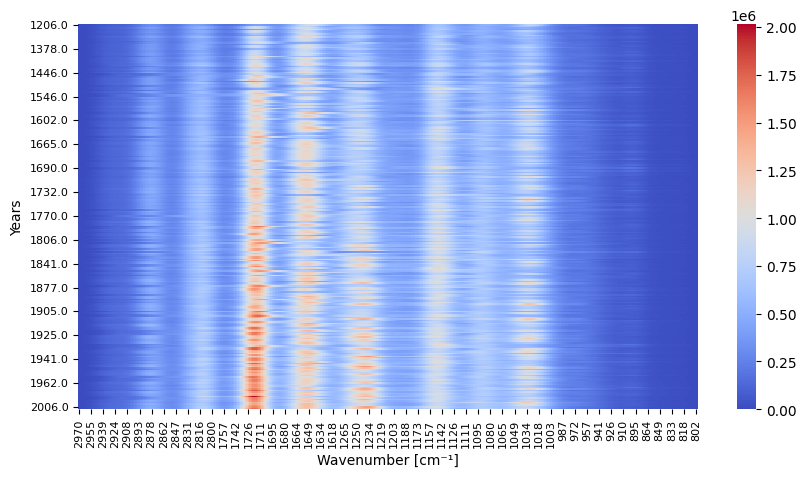

In [ ]:
# Plot Heatmap
wavelengths = xp[::8]

years = sorted_test_labels[::16]

# Plot Heatmap
plt.figure(figsize=(10, 5))
sns.heatmap(sorted_rele_data, cmap='coolwarm')
plt.xlabel('Wavenumber [cm⁻¹]')
plt.ylabel('Years')
#plt.title('Relevance Heatmap')
plt.xticks(ticks=np.arange(0.5, rele.shape[1] + 0.5, 8), labels=wavelengths, fontsize=8)
plt.yticks(ticks=np.arange(0.5, rele.shape[0] + 0.5, 16), labels=years, fontsize=8)
plt.show()